# Local에서 실행하기 위한 code
### Colab을 사용하는 경우를 위해 local에서 쉽게 파일을 압축하고 google drive에 보내기 위한 코드
- map_generator.py, environment.py가 잘 작동하는지 확인
- Source code 파일과 훈련을 재개할 model을 압축하여 google drive에 보내는 코드가 작성되어 있음
- Tensorboard server를 열거나 google drive를 wsl과 mount하는 명령어가 적혀있음 -> 이를 Terminal에 적어서 실행

### Python 파일을 검사하기 위한 사전 설정

In [1]:
# Working directory 수정: 압축할 lg_robot 폴더의 위치
# %cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
%cd /home/wrl/LG_robot_DQN

/home/wrl/LG_robot_DQN


In [2]:
# Python 파일 수정 시 자동으로 새로고침
%load_ext autoreload
%autoreload 2

## Python 파일들이 잘 수행되는지 검사

### map_generator.py

In [ ]:
from path_planner.map_generator import generate_map_by_seed_and_visualize
from path_planner.config import EnvConfig

generate_map_by_seed_and_visualize(robot_diameter=EnvConfig().robot_size, seed=128, level=4)

In [ ]:
from path_planner.utils.visualizer import visualize_saved_map, visualize_mode_map
from path_planner.config import MAP_SAVE_DIR
from path_planner.map_generator import ObstacleMap
import os

map_file_path = os.path.join(MAP_SAVE_DIR, "test", "test_map_3m3m_level3_07.npy")
visualize_saved_map(map_file_path)
visualize_mode_map(map_file_path)
 
obs_map = ObstacleMap.load_from_file(map_file_path)

### environment.py

In [ ]:
%cd /home/wrl/LG_robot_DQN
%load_ext autoreload
%autoreload 2

from path_planner.config import EnvConfig, DEFAULT_SEED
from path_planner.environment import get_args, CoverageEnv
from path_planner.utils.map_utils import make_robot_mask
from path_planner.utils.visualizer import visualize_mask
from path_planner.map_layer import MapConfigSchema
import sys

sys.argv = [" ", # 파일명이 없으므로 sys.argv[0]은 공백으로 처리
            # "--robot",
            "--see_map",
            "--see_obs",
            "--debug_reset",
            "--debug_step"]
args = get_args()
cfg = EnvConfig()
env = CoverageEnv(cfg=cfg)

# 0. Robot visualize
if args.robot:
    visualize_mask(make_robot_mask(robot_size=cfg.robot_size))

map_config = MapConfigSchema(level=1, H=None, W=None)
obs, info = env.reset(map_config=map_config)
if args.debug_reset:
    if args.see_map:
        # 1. Map visualize: Agent layer, Cleaned layer, Obstacle layer, Collision map, 
        env.show_visualized_img('layer')
        env.show_visualized_img('traj')
    if args.see_obs:
        # 2. observation visualization
        env.show_visualized_img('obs')

if args.debug_step:
    # 3. step() method
    # action_seq = [0]*150 + [1]*3 + [3]*150 + [2]*250 + [3]*100 + [1]*200
    pattern = [0]*30 + [13] + [0]*10 + [13] + [0]*30 + [14] + [0]*10 + [14]
    action_seq = pattern * 20
    for action in action_seq:
        obs, reward, terminated, truncated, info = env.step(action)
    if args.see_map:
        # 1. Map visualize: Agent layer, Cleaned layer, Obstacle layer, Collision map, 
        env.show_visualized_img('layer')
        env.show_visualized_img('traj')
    if args.see_obs:
        # 2. observation visualization
        env.show_visualized_img('obs')

### Local에서 파일 실행

In [1]:
%cd ~/LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode train
    --model_name LSTM_model_smooth_reward.pth
    --optimizer adam
    --batch_size 32
    --lr 3e-4
    --momentum 0.9
    --valid_freq 1
    --ckp_freq 1
    --valid_map_num 5
    --valid_start_point_num 1
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

/home/wrl/LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 Ti SUPER
  > VRAM: 17.17 GB
------------------------------


/home/wrl/miniconda3/envs/lgrobot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checking pre-generated maps for training...
  There are 800 maps with map size 40x40
  There are 800 maps with map size 80x80
  There are 4000 maps with map size Cropped
Using pre-generated maps for training.

Checking pre-generated maps for validation...
  There are 20 maps with map size 40x40
  There are 20 maps with map size 80x80
  There are 20 maps with map size Cropped
Using pre-generated maps for validation.



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wrl/.netrc.
wandb: Currently logged in as: poiuy45987 (lg-robot-cleaner) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


No checkpoint files found!
[Initial map size] 40x40.
[Episode 1] Starting training...
	Episode reward: 0.27048587799072266
Validation...
Validation on 40x40 map size
[Validation] Episode 1: 
	Coverage Mean = 60.26%
	Overlap Rate Mean = 134.17%
	Cleaning Time Mean = 0.68 min
	Path Reward Mean = 0.35
[Episode 2] Starting training...
	Episode reward: 0.33419185876846313
Validation...
Validation on 40x40 map size
[Validation] Episode 2: 
	Coverage Mean = 88.14%
	Overlap Rate Mean = 109.31%
	Cleaning Time Mean = 0.22 min
	Path Reward Mean = 0.44
[Episode 3] Starting training...
	Episode reward: 0.26268038153648376
Validation...
Validation on 40x40 map size
[Validation] Episode 3: 
	Coverage Mean = 73.12%
	Overlap Rate Mean = 107.47%
	Cleaning Time Mean = 0.43 min
	Path Reward Mean = 0.43
[Episode 4] Starting training...
	Episode reward: 0.4232288599014282
Validation...
Validation on 40x40 map size
[Validation] Episode 4: 
	Coverage Mean = 63.13%
	Overlap Rate Mean = 105.56%
	Cleaning Time M

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7fb32cda8530>> (for post_run_cell):


ConnectionResetError: Connection lost

/home/wrl/LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 Ti SUPER
  > VRAM: 17.17 GB
------------------------------
Checking if test maps are exist...
  There are 1 map files for testing.
Test model loaded: src/path_planner/path_planner/models/model.pth
Total Parameters     : 6,045,152 (6.05M)
Trainable Parameters : 6,045,152
Model File Size      : 23.06 MB
Use 250 maps per level for test.


Level 2 Maps:   0%|          | 0/1 [00:00<?, ?it/s]

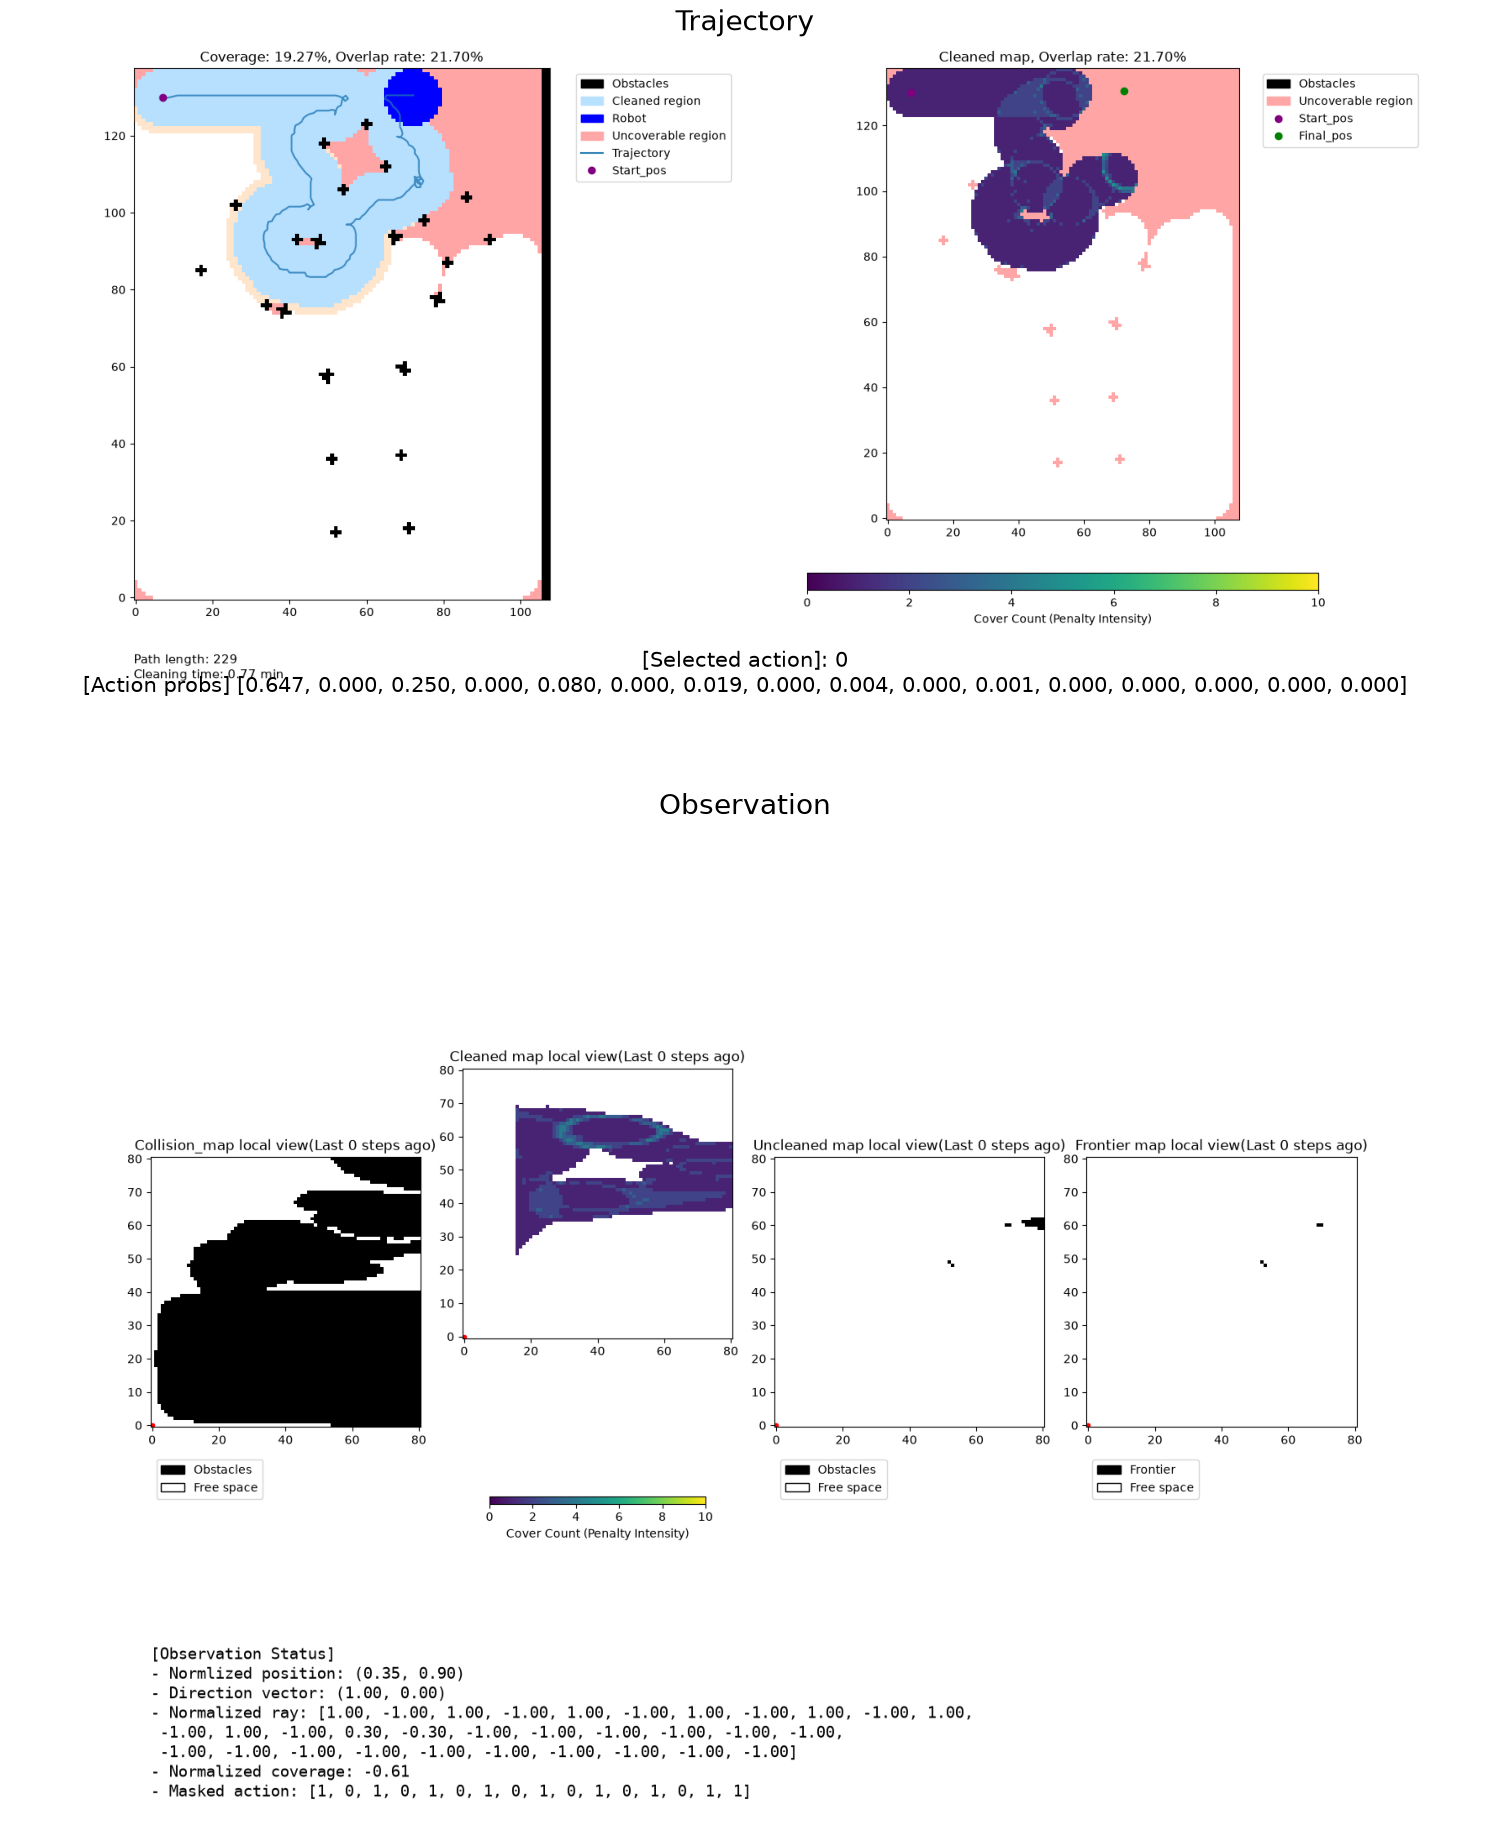

숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입

Level 2 Maps:   0%|          | 0/1 [02:34<?, ?it/s]


KeyboardInterrupt: Interrupted by user

In [ ]:
%cd ~/LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode test
    --test_map_folder_name debug_map
    --model_name model.pth
    --test_map_num_per_level 250
    --vis_test_map_num 3
"""

sys.argv = [" "] + args_str.split()

# Training
main()

/home/wrl/LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 Ti SUPER
  > VRAM: 17.17 GB
------------------------------


/home/wrl/miniconda3/envs/lgrobot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test model loaded: src/path_planner/path_planner/models/LSTM_model_smooth_reward_89.pth


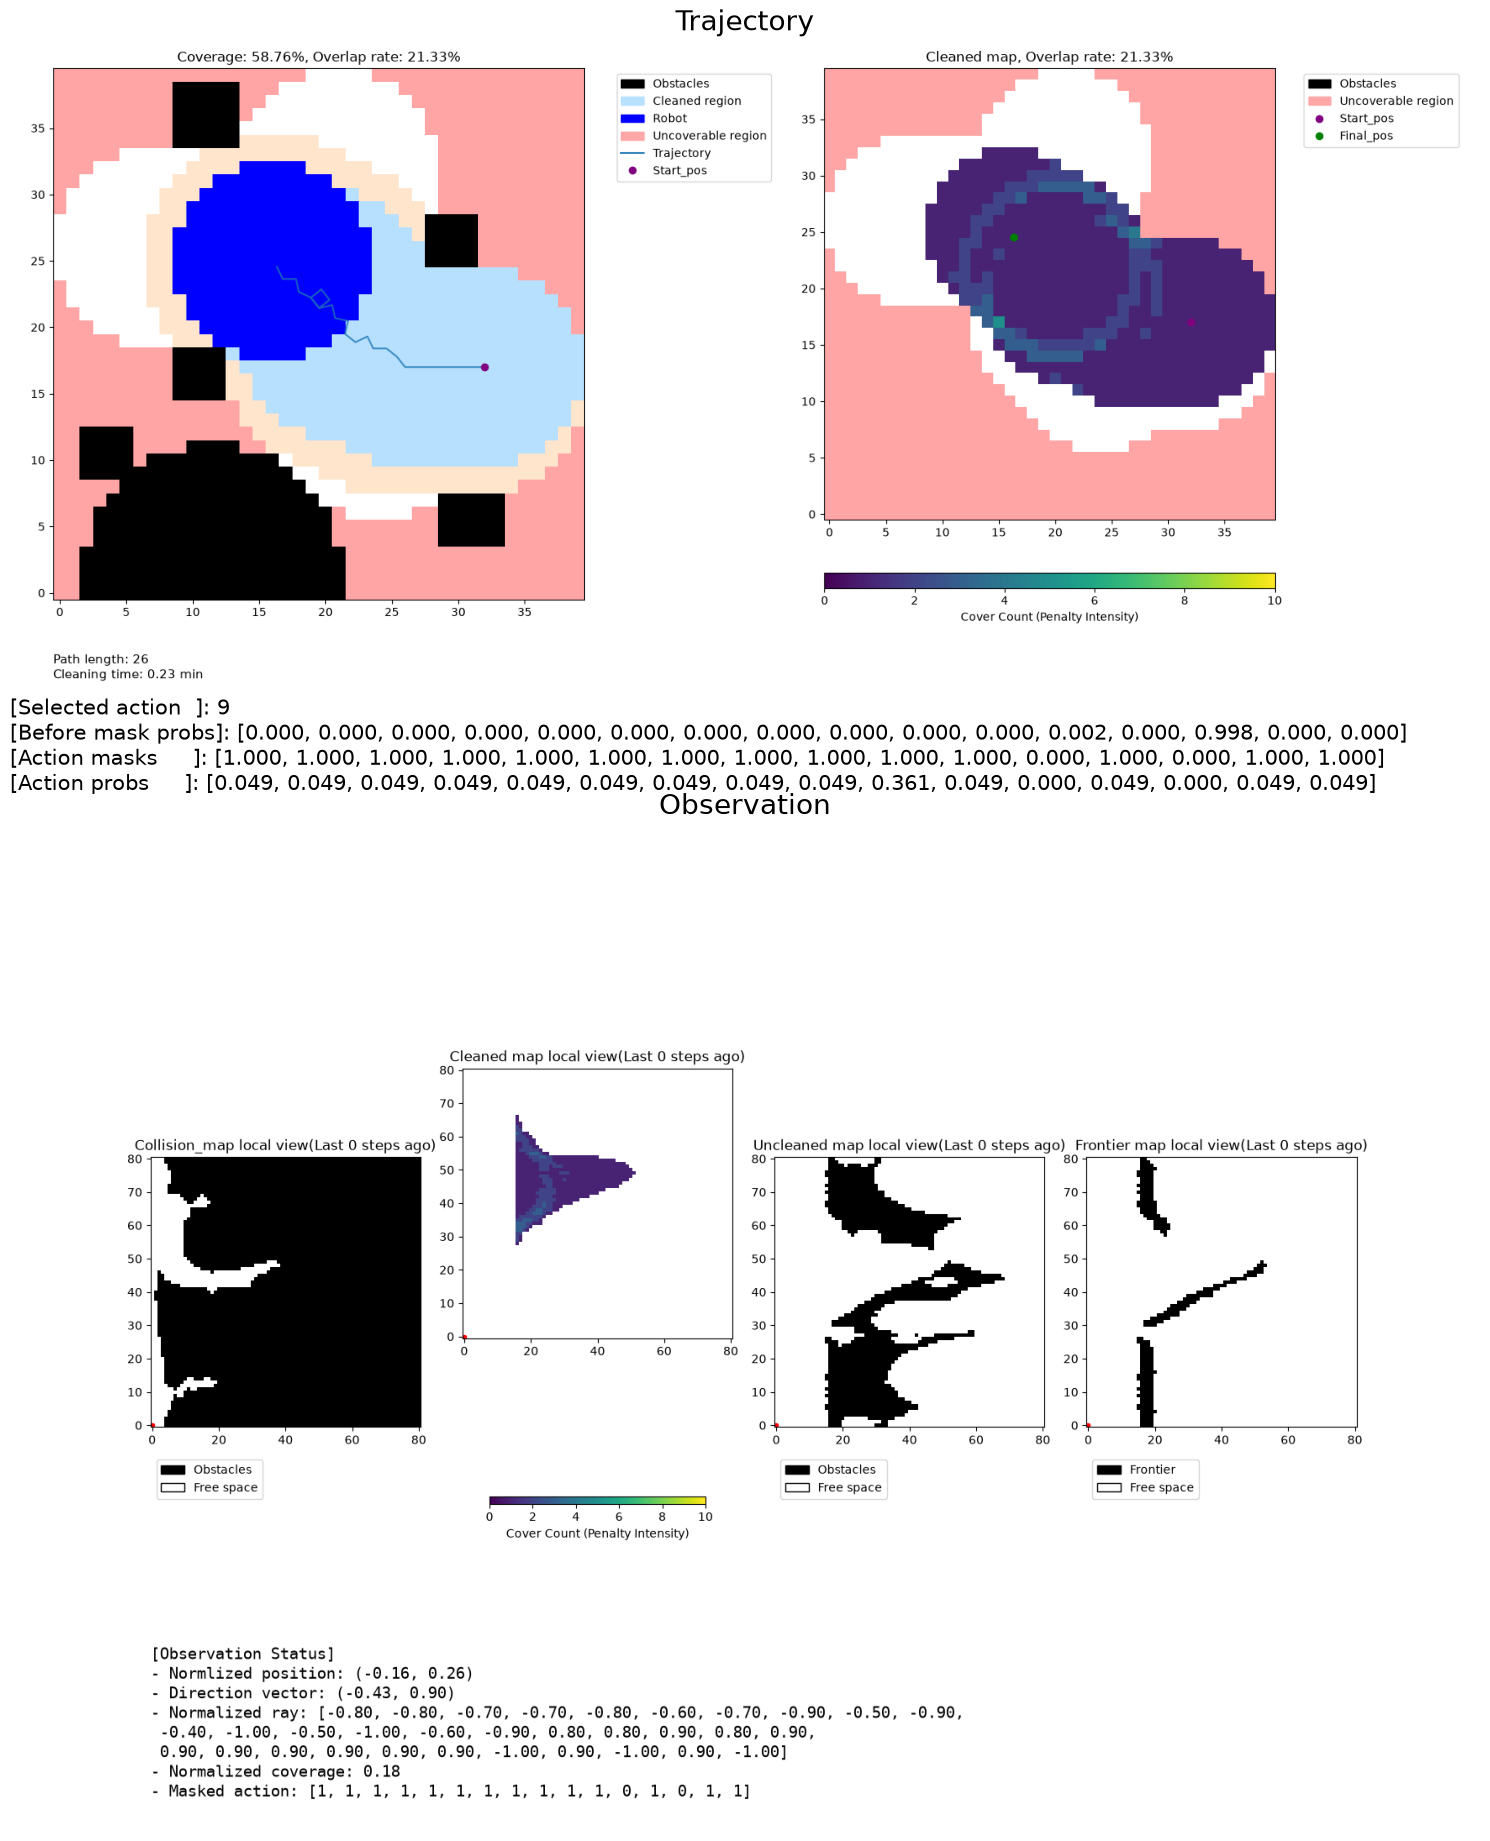

숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.
숫자 또는 'q'를 입력해주세요.


KeyboardInterrupt: Interrupted by user

In [1]:
%cd ~/LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode test_for_debug
    --map_rel_path valid/40x40/valid_map_level4_0005_40x40.npy
    --model_name LSTM_model_smooth_reward_89.pth
"""

sys.argv = [" "] + args_str.split()

# Training
main()